# 01 — Data Sourcing & Validation

## Objective
Validate the raw dataset against project requirements before proceeding to the ETL pipeline.

**Requirements Checklist:**
- Minimum 5,000 rows
- Minimum 8 meaningful columns
- Contains real-world data quality issues (missing values, type inconsistencies)
- Clear target variable for analysis

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 25)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Raw Dataset

In [2]:
# Load the raw dataset — this file should NEVER be modified
raw_path = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(raw_path)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Dataset loaded: 7,043 rows x 21 columns
Memory usage: 6984.7 KB


## 2. Shape & Structure Validation

In [3]:
# Requirement: >= 5,000 rows and >= 8 meaningful columns
print("=" * 60)
print("REQUIREMENT CHECK")
print("=" * 60)
print(f"Rows:    {df.shape[0]:,}  (requirement: >= 5,000)  {'PASS' if df.shape[0] >= 5000 else 'FAIL'}")
print(f"Columns: {df.shape[1]}    (requirement: >= 8)      {'PASS' if df.shape[1] >= 8 else 'FAIL'}")
print("=" * 60)

REQUIREMENT CHECK
Rows:    7,043  (requirement: >= 5,000)  PASS
Columns: 21    (requirement: >= 8)      PASS


In [4]:
# Column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Preview

In [5]:
# First 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Last 5 rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
# Statistical summary of numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Statistical summary of categorical columns
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 4. Data Quality Assessment

In [9]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
quality_df = quality_df[quality_df['Missing Count'] > 0]

if len(quality_df) == 0:
    print("No NULL values detected via isnull().")
    print("\nChecking for blank strings and whitespace-only values...")
    
# Check for blank strings (common in CSVs where missing != NaN)
blank_counts = {}
for col in df.select_dtypes(include='object').columns:
    blanks = (df[col].str.strip() == '').sum()
    if blanks > 0:
        blank_counts[col] = blanks

if blank_counts:
    print("\nBlank string values found:")
    for col, count in blank_counts.items():
        print(f"  {col}: {count} blanks ({count/len(df)*100:.2f}%)")
else:
    print("No blank strings found either.")

No NULL values detected via isnull().

Checking for blank strings and whitespace-only values...

Blank string values found:
  TotalCharges: 11 blanks (0.16%)


## 5. Column-Level Analysis

In [10]:
# Unique value counts for each column
print(f"{'Column':<20} {'Dtype':<10} {'Unique':>7} {'Sample Values'}")
print("-" * 80)
for col in df.columns:
    uniq = df[col].nunique()
    samples = df[col].dropna().unique()[:3]
    sample_str = ', '.join(str(s) for s in samples)
    print(f"{col:<20} {str(df[col].dtype):<10} {uniq:>7}   {sample_str}")

Column               Dtype       Unique Sample Values
--------------------------------------------------------------------------------
customerID           object        7043   7590-VHVEG, 5575-GNVDE, 3668-QPYBK
gender               object           2   Female, Male
SeniorCitizen        int64            2   0, 1
Partner              object           2   Yes, No
Dependents           object           2   No, Yes
tenure               int64           73   1, 34, 2
PhoneService         object           2   No, Yes
MultipleLines        object           3   No phone service, No, Yes
InternetService      object           3   DSL, Fiber optic, No
OnlineSecurity       object           3   No, Yes, No internet service
OnlineBackup         object           3   Yes, No, No internet service
DeviceProtection     object           3   No, Yes, No internet service
TechSupport          object           3   No, Yes, No internet service
StreamingTV          object           3   No, Yes, No internet service

In [11]:
# Value counts for categorical columns (<=10 unique values)
for col in df.columns:
    if df[col].nunique() <= 10:
        print(f"\n{'=' * 40}")
        print(f"{col}")
        print(f"{'=' * 40}")
        counts = df[col].value_counts()
        for val, count in counts.items():
            print(f"  {val:<30} {count:>5}  ({count/len(df)*100:.1f}%)")


gender
  Male                            3555  (50.5%)
  Female                          3488  (49.5%)

SeniorCitizen
  0                               5901  (83.8%)
  1                               1142  (16.2%)

Partner
  No                              3641  (51.7%)
  Yes                             3402  (48.3%)

Dependents
  No                              4933  (70.0%)
  Yes                             2110  (30.0%)

PhoneService
  Yes                             6361  (90.3%)
  No                               682  (9.7%)

MultipleLines
  No                              3390  (48.1%)
  Yes                             2971  (42.2%)
  No phone service                 682  (9.7%)

InternetService
  Fiber optic                     3096  (44.0%)
  DSL                             2421  (34.4%)
  No                              1526  (21.7%)

OnlineSecurity
  No                              3498  (49.7%)
  Yes                             2019  (28.7%)
  No internet service           

## 6. Target Variable — Churn

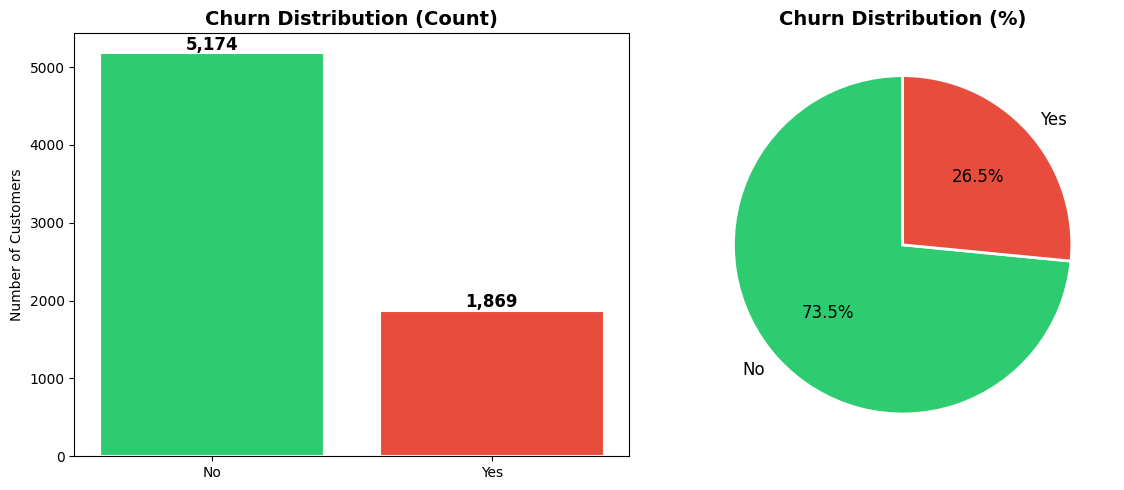


Churn Rate: 26.5%
Retained:   5,174 customers
Churned:    1,869 customers


In [12]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, (val, count) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, count + 50, f'{count:,}', ha='center', fontsize=12, fontweight='bold')

# Percentage pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../tableau/screenshots/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.1f}%")
print(f"Retained:   {churn_counts['No']:,} customers")
print(f"Churned:    {churn_counts['Yes']:,} customers")

## 7. Duplicate Check

In [13]:
# Check for duplicate customer IDs
dup_ids = df['customerID'].duplicated().sum()
print(f"Duplicate customerIDs: {dup_ids}")

# Check for fully duplicate rows (excluding customerID)
dup_rows = df.drop(columns=['customerID']).duplicated().sum()
print(f"Duplicate rows (all features): {dup_rows}")

Duplicate customerIDs: 0
Duplicate rows (all features): 22


## 8. Validation Summary

### Requirements Assessment

| Requirement | Status | Details |
|---|---|---|
| >= 5,000 rows | **PASS** | 7,043 rows |
| >= 8 meaningful columns | **PASS** | 19 meaningful feature columns + 1 target + 1 ID |
| Contains data quality issues | **PASS** | 11 blank TotalCharges values, type inconsistency (TotalCharges as string), SeniorCitizen 0/1 encoding |
| Clear target variable | **PASS** | `Churn` column with 26.5% positive rate |
| No duplicate records | **PASS** | All customerIDs unique |

### Key Observations for ETL Pipeline

1. **`TotalCharges`** has 11 blank values — these correspond to customers with `tenure = 0` (new sign-ups who haven't been billed). The column is also stored as a string and must be converted to float.
2. **`SeniorCitizen`** uses 0/1 encoding while all other categorical columns use Yes/No — needs standardization.
3. **No time/date column** — the dataset is a cross-sectional snapshot. `tenure` will serve as the time proxy.
4. **Class imbalance** in target: 73.5% No / 26.5% Yes — notable but not extreme. No resampling needed for descriptive analytics.

### Conclusion
The dataset meets all project requirements and is approved for the ETL pipeline phase.

---
*Proceed to: `02_cleaning.ipynb`*